In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from scipy import stats

In [2]:
anime_data_path = 'data/anime_processed.parquet'
anime_df = pd.read_parquet(anime_data_path)
anime_df.head(3)

,mal_id,title_english,type,source,episodes,duration,rating,score,scored_by,rank,popularity,members,favorites,year,demographics,studios,genres,themes
0,1,Cowboy Bebop,TV,Original,26,24,R - 17+ (violence & profanity),8.75,1062212,49,41,2057323,89639,1998,[],[Sunrise],"[Action, Award Winning, Sci-Fi]","[Adult Cast, Space]"
1,5,Cowboy Bebop: The Movie,Movie,Original,1,115,R - 17+ (violence & profanity),8.38,232423,240,659,412138,1785,2001,[],[Bones],"[Action, Sci-Fi]","[Adult Cast, Space]"
2,6,Trigun,TV,Manga,26,24,PG-13 - Teens 13 or older,8.22,401751,424,266,834750,17659,1998,[Shounen],[Madhouse],"[Action, Adventure, Sci-Fi]",[Adult Cast]


In [3]:
# drop nan values
cols_to_check = anime_df.columns.difference(["rank", "episodes"])
anime_df = anime_df.dropna(subset=cols_to_check)


# Basic exploratory analysis

In [4]:
# =========================
# BASIC EXPLORATORY ANALYSIS
# =========================

# 1. Find the top 20 highest-rated anime.
# anime_df.sort_values('score', axis=1)['title_english']

res_1 = (anime_df
 .sort_values('score', inplace=False, ascending=False)
 .head(20)[['title_english', 'score']]
 )

# res_1


In [5]:

# 2. Find the most popular anime by:
#    - members
#    - favorites
#    - popularity rank

def most_by(df: pd.DataFrame, key, n=5):
    return (
        df
        .sort_values(key, ascending=False)
        .head(n)[['title_english', key]]
    )


by_members = most_by(anime_df, 'members')
by_favorites = most_by(anime_df, 'favorites')
by_popularity = (
    anime_df
    .copy()
    .sort_values('popularity', ascending=True)
    .head()[['title_english', 'popularity']]
)


count    4972.000000
mean        6.652120
std         0.854627
min         1.890000
25%         6.137500
50%         6.760000
75%         7.250000
max         9.110000
Name: score, dtype: float64


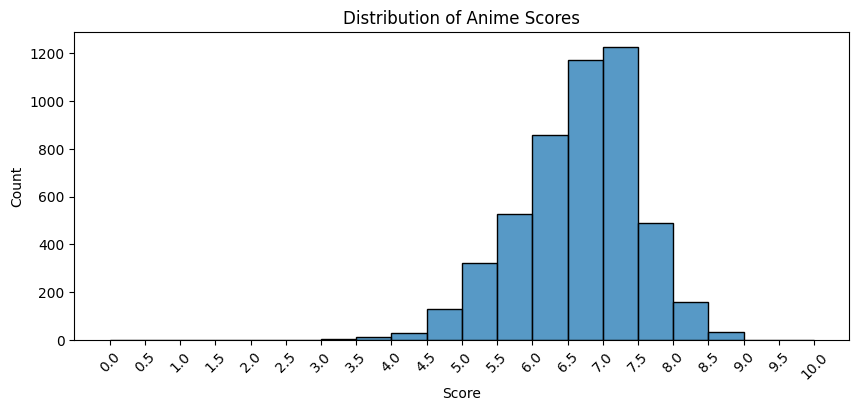

In [6]:

# 3. Analyze score distribution:
#    - mean
#    - median
#    - standard deviation
#    - histogram
print(anime_df['score'].describe())

scores = anime_df['score']
bins = np.arange(0, 10.5, 0.5)

plt.figure(figsize=(10, 4))

# sns.histplot(scores, bins=bins, kde=True)
sns.histplot(scores, bins=bins, kde=False)

plt.title("Distribution of Anime Scores")
plt.xlabel("Score")
plt.ylabel("Count")

plt.xticks(bins, rotation=45)

plt.show()

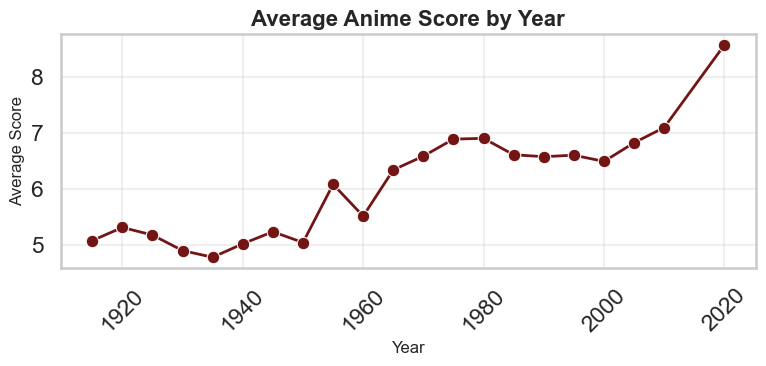

In [7]:
# 4. Analyze anime production by year.

years = anime_df['year']

# average scores by years (bins of 5)
anime_score_year = anime_df[['year', 'score']]
years_binned = pd.Series(years) // 5 * 5
anime_scores_binned = pd.concat((years_binned, anime_df['score']), axis=1)

# in 2020th no anime bcz didnt parse data enough yet
# sns.histplot(years, bins=np.arange(years.min(), years.max(), 5))


avg_score_by_years = (
    anime_scores_binned
    .groupby('year')
    .mean()
)

sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(8, 4))
sns.lineplot(
    data=avg_score_by_years,
    x="year",
    y="score",
    marker="o",
    linewidth=2,
    color="#731515"
)

plt.title("Average Anime Score by Year", fontsize=16, weight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Score", fontsize=12)

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()


# anime_scores_binned

# Results:
# there's a growing trend in number of animes (more animes each year)
# can see average score growth as year proceeds (does this mean that with time anime got better?)



In [8]:
# 5. Find the most common anime types:
#    TV, Movie, OVA, ONA, Special, etc.
(
    anime_df
    .groupby('type')['type']
    .count()
)


type
CM               3
Movie          832
Music           42
ONA             65
OVA           1711
PV               1
Special        319
TV            1860
TV Special     139
Name: type, dtype: int64

In [9]:
# 6. Find the most common source materials:
#    Manga, Original, Light Novel, Game, etc.
(
    anime_df
    .groupby('source')['source']
    .count()
    .sort_values(ascending=False)
)

source
Manga           1822
Original        1294
Visual novel     574
Unknown          354
Game             223
Light novel      204
Novel            197
Other            158
Book              51
4-koma manga      42
Picture book      23
Card game         10
Mixed media        8
Music              5
Web manga          4
Radio              3
Name: source, dtype: int64

<Axes: xlabel='episodes', ylabel='Count'>

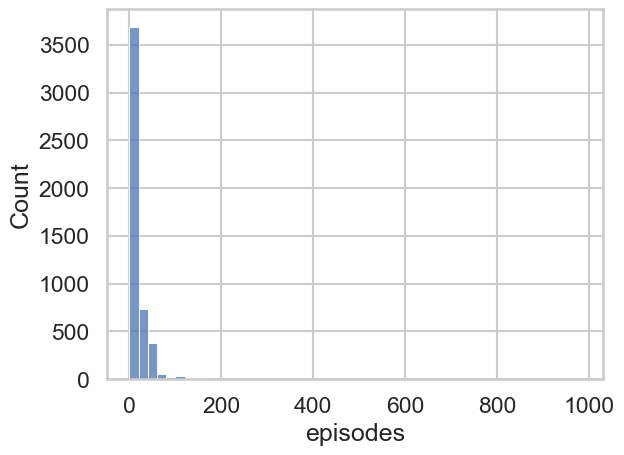

In [10]:
# 7. Analyze episode count distribution.
ep_min = anime_df['episodes'].min()
ep_max = anime_df['episodes'].max()
sns.histplot(anime_df['episodes'], bins=np.arange(ep_min, 1000, 20))


<Axes: xlabel='duration', ylabel='Count'>

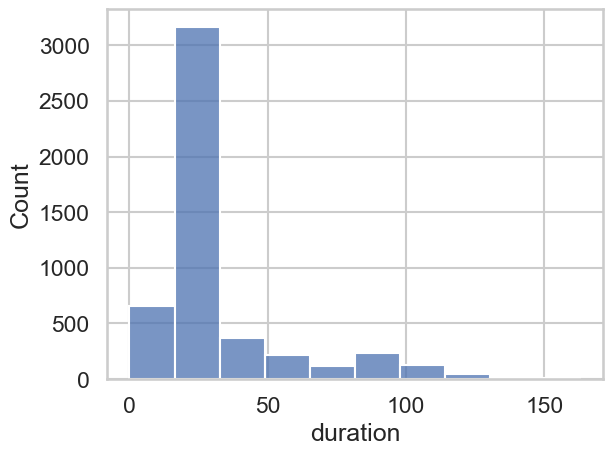

In [11]:
# 8. Analyze duration distribution.
duration = anime_df['duration']
sns.histplot(duration, bins=10)


In [12]:
# 9. Find anime with:
#    - highest score
hi_score = (
    anime_df
    .sort_values('score', ascending=False)[['title_english', 'score']]
    .iloc[0]
    .to_list()
)
print('Highest score: ', hi_score, sep='\n')

#    - lowest score
lo_score = (
    anime_df
    .sort_values('score', ascending=True)[['title_english', 'score']]
    .iloc[0]
    .to_list()
)
print('Lowest score: ', lo_score, sep='\n')

#    - most favorites
most_fav = (
    anime_df
    .sort_values('favorites', ascending=False)[['title_english', 'favorites']]
    .iloc[0]
    .to_list()
)
print('Most favorites: ', most_fav, sep='\n')

#    - most members
most_members = (
    anime_df
    .sort_values('members', ascending=False)[['title_english', 'members']]
    .iloc[0]
    .to_list()
)
print('Most members: ', most_members, sep='\n')


Highest score: 
['Fullmetal Alchemist: Brotherhood', np.float64(9.11)]
Lowest score: 
['Skelter Heaven', np.float64(1.89)]
Most favorites: 
['One Piece', np.int64(252104)]
Most members: 
['Death Note', np.int64(4300530)]


# GENRES / THEMES / DEMOGRAPHICS

In [13]:
# =========================
# GENRES / THEMES / DEMOGRAPHICS
# =========================
# problem: anime can have more than 1 genre
# how to split anime by genres? so that we have many anime rows that contain those genres
# 

# 10. Find the most common genres.
genres = anime_df['genres']
common_genres = (
    genres
    .explode()
    .value_counts()
    .iloc[:5]
)
common_genres


genres
Comedy       1728
Adventure    1350
Sci-Fi       1333
Action       1173
Drama        1082
Name: count, dtype: int64

In [14]:
# 11. Find the highest-rated genres.
(
    anime_df[['score', 'genres']]
    .explode('genres')
    .rename(columns={'genres': 'genre'})
    .groupby('genre')['score']
    .agg(
        avg_score="mean",
        count="size"
    )
    .sort_values('avg_score', ascending=False)
    .iloc[:10]
)

,avg_score,count
genre,,
Award Winning,7.363089,123
Suspense,7.328762,105
Mystery,7.141474,312
Slice of Life,7.074066,91
Sports,6.997730,185
Drama,6.993364,1082
Gourmet,6.992500,20
Romance,6.939452,803
Adventure,6.893467,1350


In [15]:
# 12. Find the most popular genres.
# ----- sum members - doesnt tell much about genre popularity, 
# it can be that its a lot animes with this genre
# ----- Avg members over count of animes with this genre
# will be more informative i think
(
    anime_df[['members', 'genres']]
    .explode('genres')
    .rename(columns={'genres': 'genre'})
    .groupby('genre')['members']
    .agg(
        anime_count='size',
        sum_members='sum'
    )
    .assign(ratio=lambda x: x['sum_members'] / x['anime_count'])
    .sort_values('ratio', ascending=False)
    .head()
)



,anime_count,sum_members,ratio
genre,,,
Suspense,105,31978612,304558.209524
Award Winning,123,36513581,296858.382114
Avant Garde,55,8388678,152521.418182
Supernatural,393,45527592,115846.290076
Mystery,312,35570045,114006.554487


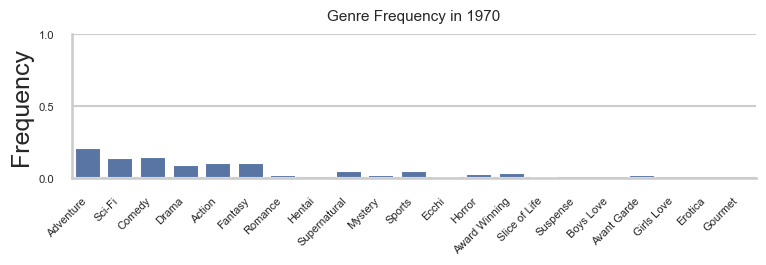

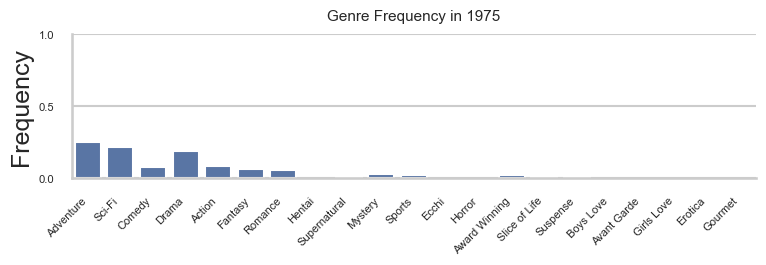

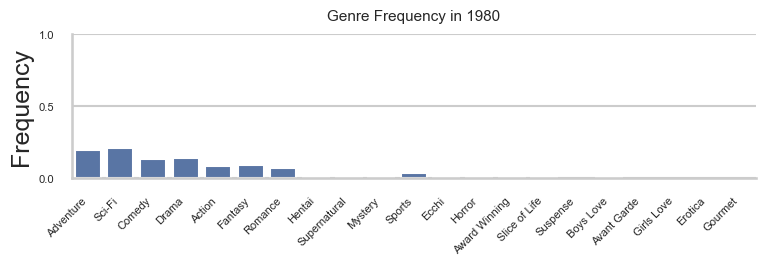

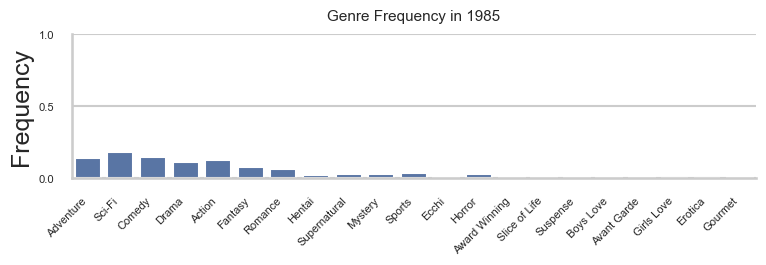

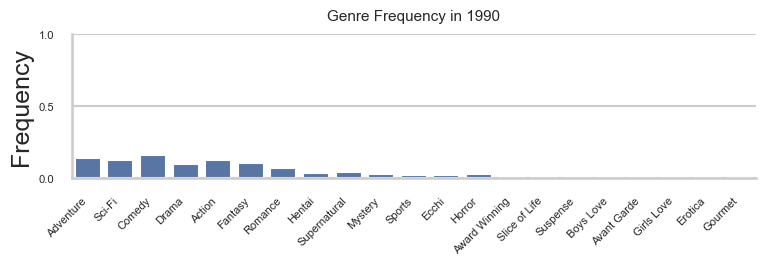

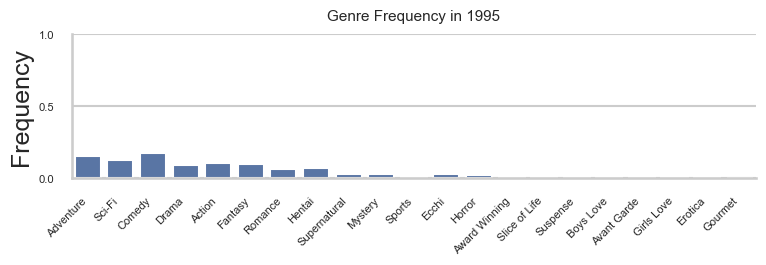

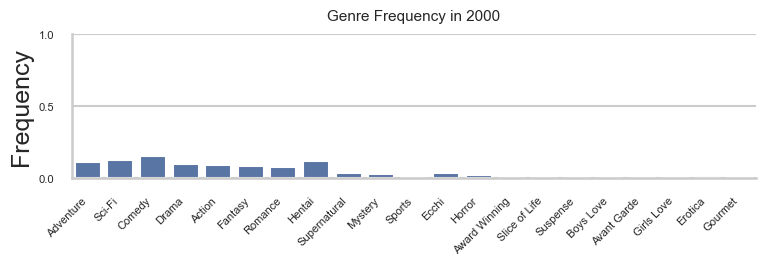

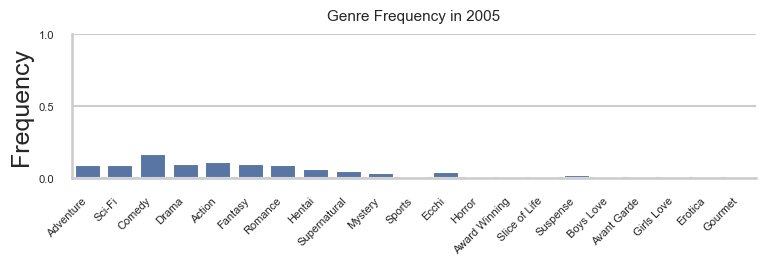

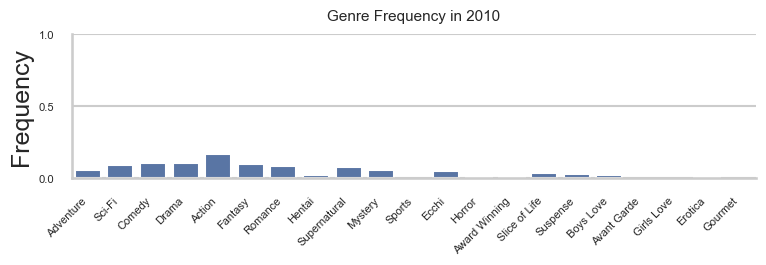

In [16]:
# 13. Analyze genre trends over time.
# count genres by year bins

genres_by_years = (
    anime_df[['year', 'genres']]
    .assign(year_bin=lambda x: x['year'] // 5 * 5)
    .explode('genres')
    .rename(columns={'genres': 'genre'})
    .groupby(['year_bin', 'genre'])
    .size()
    .reset_index(name='count')
    .sort_values(['year_bin', 'count'], ascending=[True, False])
    .groupby('year_bin')['genre']
    .agg(genres=list)['genres']
)

active_year_bins = (
    anime_df[['year']]
    .assign(year_bin=lambda x: x['year'] // 5 * 5)
    .groupby(['year_bin'])
    .agg(count=('year_bin', 'size'))
    .query('count > 50')
    .index
    .to_list()
)

active_years_genres = (
    anime_df[['year', 'genres']]
    .assign(year_bin=lambda x: x['year'] // 5 * 5)
    .explode('genres')
    .rename(columns={'genres': 'genre'})
    .loc[lambda s: s['year_bin'].isin(active_year_bins)]  # year_bin == active_year_bins
)

active_genre_counts = (
    anime_df[['year', 'genres']]
    .assign(year_bin=lambda x: x['year'] // 5 * 5)
    .explode('genres')
    .rename(columns={'genres': 'genre'})
    .loc[lambda s: s['year_bin'].isin(active_year_bins)]
    .groupby(['year_bin', 'genre'])
    .size()
    .reset_index(name='count')
)

total_genre_count_per_bin = (
    active_genre_counts
    .groupby('year_bin')['count']
    # .sum()
    .transform('sum')
)

# total_genre_count_per_bin
genre_frequencies = active_genre_counts.copy()
genre_frequencies['freq'] = genre_frequencies['count'] / total_genre_count_per_bin

genre_order = (
    genre_frequencies
    .groupby("genre")["freq"]
    .mean()
    .sort_values(ascending=False)
    .index
)

# just checked if it worked correctly 
# (
#     genre_frequency
#     .groupby('year_bin')['freq']
#     .sum()
# )

sns.set_style("whitegrid")

for year, group in genre_frequencies.groupby("year_bin"):
    plt.figure(figsize=(8, 3))

    ax = sns.barplot(
        data=group,
        x="genre",
        y="freq",
        order=genre_order
    )

    ax.set_title(f"Genre Frequency in {year}", fontsize=11, pad=10)
    ax.set_xlabel("")
    ax.set_ylabel("Frequency")

    # 👇 key improvements
    plt.xticks(rotation=45, fontsize=8, ha="right")
    plt.yticks(fontsize=8)

    plt.ylim(0, 1)

    sns.despine()  # removes top/right borders → cleaner look

    plt.tight_layout()
    plt.show()

In [17]:
# 14. Find the most common themes.
common_themes = (
    anime_df['themes']
    .explode()
    .value_counts()
    .head(10)
)
common_themes


themes
Mecha            586
School           488
Historical       327
Military         289
Space            288
Adult Cast       225
Super Power      199
Martial Arts     160
Harem            153
Psychological    150
Name: count, dtype: int64

C:\Users\Artem\AppData\Local\Temp\ipykernel_10268\3778143918.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Artem\AppData\Local\Temp\ipykernel_10268\3778143918.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
C:\Users\Artem\AppData\Local\Temp\ipykernel_10268\3778143918.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Artem\AppData\Local\Temp\ipykernel_10268\3778143918.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLoca

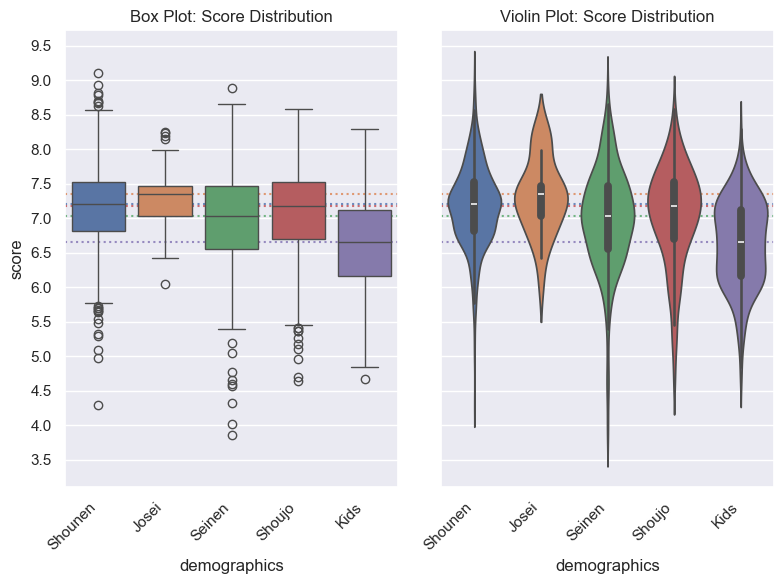

In [18]:
# 15. Compare score distributions between demographics:
#     Shounen, Seinen, Shoujo, Josei, etc.

demo_groups = (
    anime_df[['demographics', 'score']]
    .explode('demographics')
    .dropna()
    .groupby('demographics')
)
demo_scores = {demo: group['score'] for demo, group in demo_groups}

plot_data = anime_df.explode('demographics').dropna()
unique_demographics = plot_data['demographics'].unique()
medians = plot_data.groupby('demographics')['score'].median()
palette = sns.color_palette(n_colors=len(unique_demographics))
sns.set_theme()

fig, axes = plt.subplots(1, 2, figsize=(8, 6), sharex=True, sharey=True)

# Left Plot: Box Plot
sns.boxplot(
    data=plot_data,
    x='demographics',
    y='score',
    palette=palette,  # Explicitly pass the palette so colors lock in perfectly
    ax=axes[0]
)
axes[0].set_title("Box Plot: Score Distribution")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Right Plot: Violin Plot
sns.violinplot(
    data=plot_data,
    x='demographics',
    y='score',
    palette=palette,  # Match the violin colors exactly
    ax=axes[1]
)
axes[1].set_title("Violin Plot: Score Distribution")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylabel("") 

# Set the y-axis intervals to 0.5
axes[0].yaxis.set_major_locator(ticker.MultipleLocator(0.5))

# 4. Loop through each demographic, find its color and median, and draw the line
for ax in axes:
    for i, demographic in enumerate(unique_demographics):
        median_val = medians[demographic]
        group_color = palette[i]  # Pull the matching color for this specific group
        
        ax.axhline(
            y=median_val, 
            color=group_color, 
            linestyle=':', 
            linewidth=1.5, 
            alpha=0.8,
            zorder=0  # Keeps the reference line behind the box/violin plots
        )

plt.tight_layout()
plt.show()


In [19]:
# 16. Analyze which demographics are most popular.
(
    anime_df[['demographics']]
    .explode('demographics')
    .groupby('demographics')
    .size()
    .sort_values(ascending=False)
)


demographics
Shounen    775
Seinen     365
Kids       297
Shoujo     243
Josei       29
dtype: int64

# Studio Analysis

In [20]:
# =========================
# STUDIO ANALYSIS
# =========================

# 17. Find the most productive studios.
# one anime can have more than 1 studio
# by productive means original work and collaborations?
(
    anime_df[['studios']]
    .explode('studios')
    .groupby('studios')
    .size()
    .sort_values(ascending=False)
)

anime_studio_count = (
    anime_df[['title_english', 'year', 'studios', 'score']]
    .assign(studios_count=lambda df: df['studios'].str.len().fillna(1).astype(int))
)

# foreach studio find min and max year of solo works
# and then find average animes every year
solo_animes = (
    anime_studio_count
    .query('studios_count == 1')
    .assign(studios=lambda s: s['studios'].str[0])
    .drop('studios_count', axis=1)
)

studio_lifespans = (
    solo_animes[['year', 'studios']]    
    .groupby('studios')['year']
    .agg(['min', 'max'])
    .assign(years_active=lambda s: s['max'] - s['min'])
    .sort_index()['years_active'] + 1
)

solo_counts = (
    solo_animes[['year', 'studios']]
    .groupby('studios')
    .size()
    .sort_index()
)

solo_productivity = solo_counts / studio_lifespans
solo_productivity.sort_values(ascending=False)


studios
Sunrise                   7.111111
Toei Animation            6.946429
J.C.Staff                     6.72
Madhouse                  5.944444
Gonzo                     5.833333
                            ...   
Oh! Production            0.148148
DAX Production            0.129032
Minami Machi Bugyousho         0.1
Animation Staff Room      0.076923
Tokyo Movie               0.066667
Length: 364, dtype: Float64

In [21]:
# 18. Find studios with highest average scores.
mean_score_studios = (
    anime_df[['studios', 'score']]
    .explode('studios')
    .groupby('studios')
    .mean()
    .sort_values('score', ascending=False)
)
mean_score_studios.head()


,score
studios,
K-Factory,8.403333
Nippon Ramayana Film,8.380000
Graphinica,8.340000
Khara,8.137500
8bit,7.830000


In [22]:
# 19. Find studios with highest average popularity.
(
    anime_df[['studios', 'members']]
    .explode('studios')
    .groupby('studios')
    .mean().astype(int)
    .sort_values('members', ascending=False)
    .reset_index()
    .head()
)


,studios,members
0,Graphinica,1020230
1,Manglobe,761856
2,P.A. Works,544114
3,Khara,533016
4,Bones,359282


Text(0.5, 0.98, 'Studio Performance Matrix: Scores, Members, and Favorites')

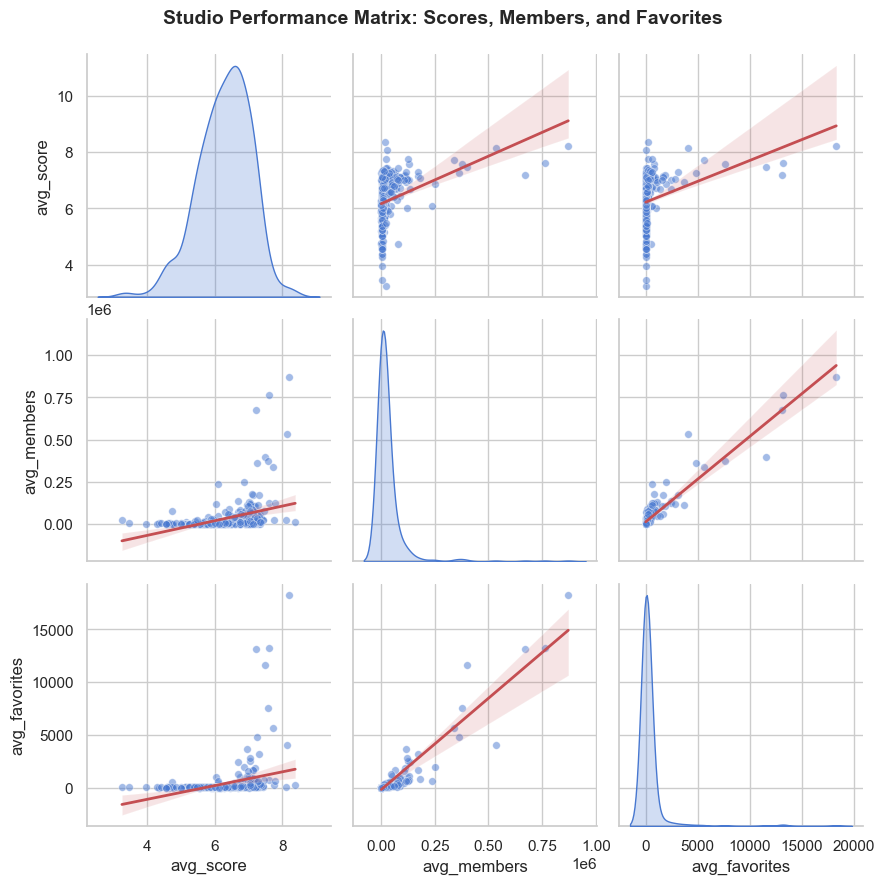

In [23]:
# 20. Analyze relationship between:
#     studio productivity vs average score.

solo_animes = (
    anime_df[['title_english', 'year', 'studios', 'score', 'members', 'favorites']]
    .assign(studios_count=lambda df: df['studios'].str.len().fillna(1).astype(int))
    .query('studios_count == 1')
    .assign(studios=lambda s: s['studios'].str[0])
    .drop('studios_count', axis=1)
)

s_mean_members = (
    solo_animes[['studios', 'members']]
    .groupby('studios')['members']
    .mean()
    .sort_index()
)

s_mean_favorites = (
    solo_animes[['studios', 'favorites']]
    .groupby('studios')['favorites']
    .mean()
    .sort_index()
)

s_mean_score = (
    solo_animes[['studios', 'score']]
    .groupby('studios')['score']
    .mean()
    .sort_index()
)

studio_analysis_df = pd.concat(
    {
        "avg_score": s_mean_score,
        "avg_members": s_mean_members,
        "avg_favorites": s_mean_favorites,
    },
    axis=1,
).dropna()

sns.set_theme(style="whitegrid", palette="muted")

g = sns.pairplot(
    data=studio_analysis_df,
    kind="reg",  # Adds linear regression lines + confidence intervals
    diag_kind="kde",  # Shows smooth distribution curves on the diagonal
    plot_kws={
        "scatter_kws": {
            "alpha": 0.5,
            "s": 30,
            "linewidths": 0.5,
            "edgecolor": "w",
        },
        "line_kws": {"color": "#C44E52", "linewidth": 2},
    },
    height=3,
)

# 4. Add clean titles and rendering configuration
g.figure.subplots_adjust(top=0.93)
g.figure.suptitle(
    "Studio Performance Matrix: Scores, Members, and Favorites",
    fontsize=14,
    fontweight="bold",
)



C:\Users\Artem\AppData\Local\Temp\ipykernel_10268\2670096445.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


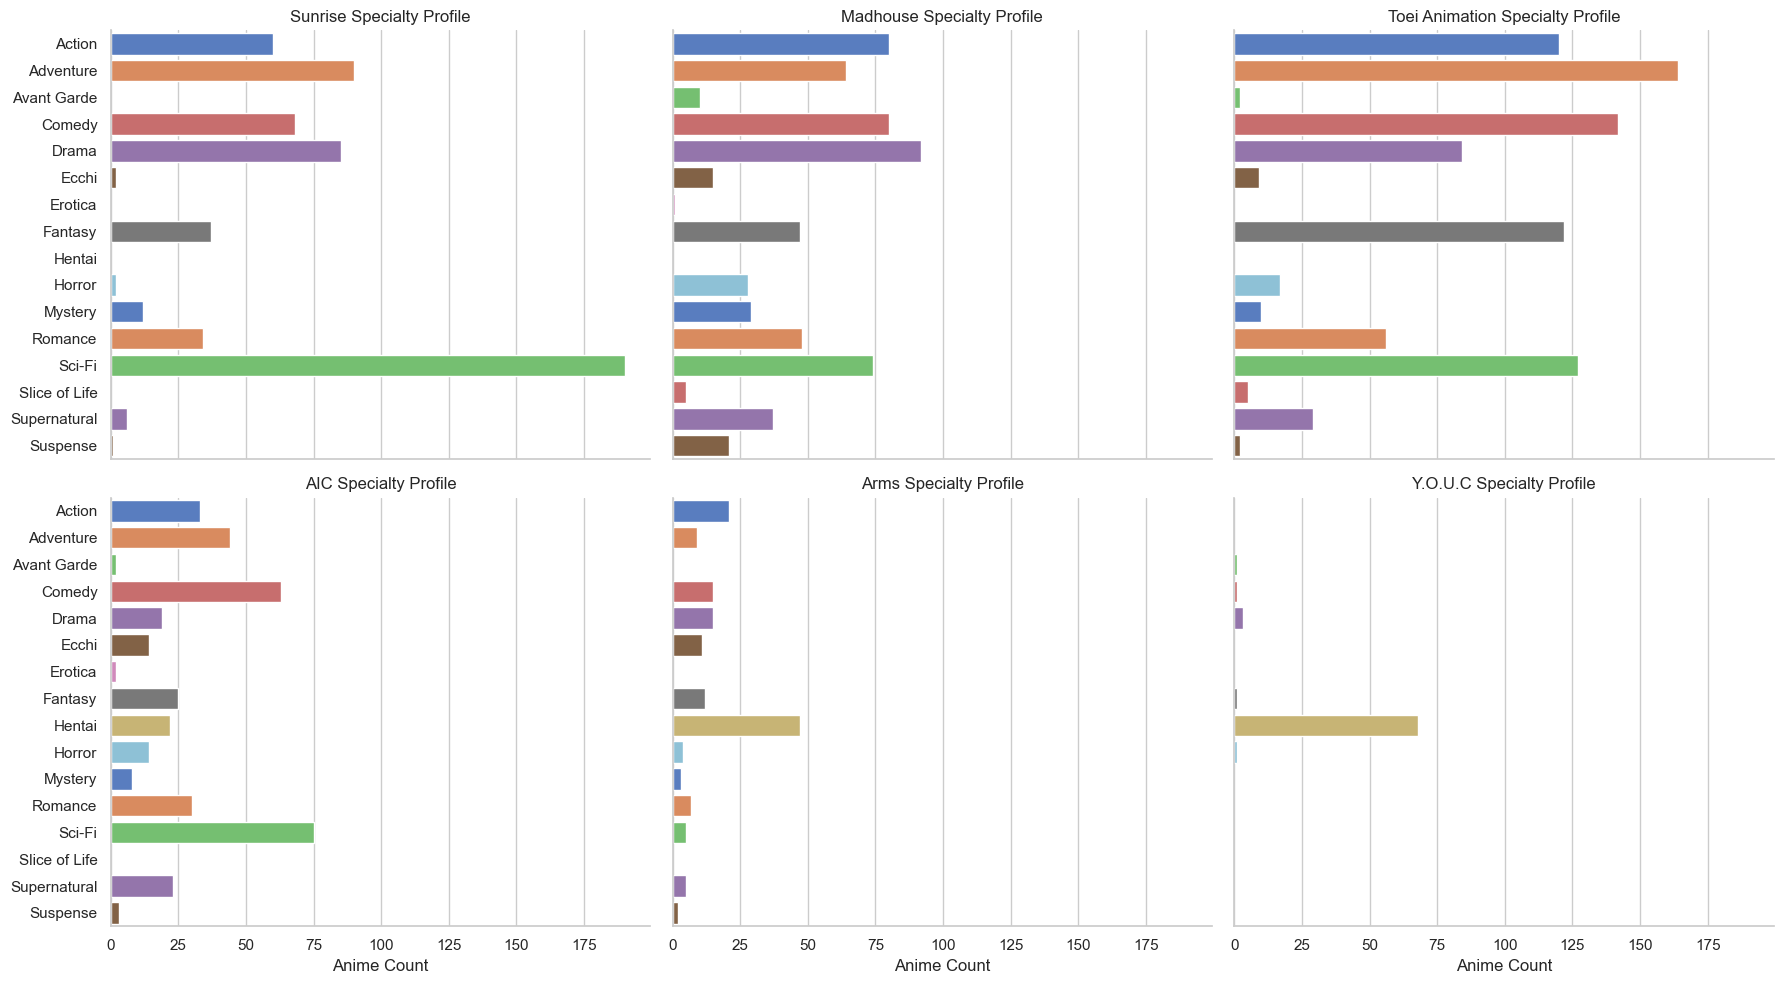

In [24]:
# 21. Find studios specializing in certain genres.

studios_i_want = ["Sunrise", "Madhouse", "Toei Animation", 'AIC', 'Arms', 'Y.O.U.C']
all_genres = (
    anime_df["genres"].explode().dropna().astype(str).unique()
)
excluded_genres = {"Award Winning", "Gourmet", "Sports", "Boys Love", "Girls Love"}
genres_i_want = list(set(all_genres) - excluded_genres)

# 3. Explode and filter
plot_data = (
    anime_df[["studios", "genres"]]
    .explode("studios")
    .explode("genres")
    .query("studios in @studios_i_want and genres in @genres_i_want")
    .dropna()
)

# 4. Plot using col_wrap so 6 studios don't squish into one infinite horizontal line
sns.set_theme(style="whitegrid")

g = sns.catplot(
    data=plot_data,
    y="genres",
    kind="count",
    col="studios",
    col_order=studios_i_want,
    order=sorted(genres_i_want),  # Alphabetical sorting makes comparisons easier
    col_wrap=3,  # Wraps the 6 studios into a clean 2x3 grid layout
    palette="muted",
    height=5,
    aspect=1.2,
)

g.set_titles("{col_name} Specialty Profile")
g.set_axis_labels("Anime Count", "")
plt.tight_layout()

plt.show()

In [25]:
hentai_studios = (
    anime_df[['studios', 'genres']]
    .explode('studios')
    .explode('genres')
    .dropna()
    .query('genres == "Hentai"')
    .groupby('studios')
    .size()
    .sort_values(ascending=False)
)

hentai_studios

studios
Y.O.U.C             68
Arms                47
T-Rex               28
Studio Jam          27
Triple X            25
                    ..
Sumomo Film          1
Twenty First         1
Tsubo Production     1
Tryforce             1
Zyc                  1
Length: 137, dtype: int64

# RELATIONSHIPS / CORRELATIONS


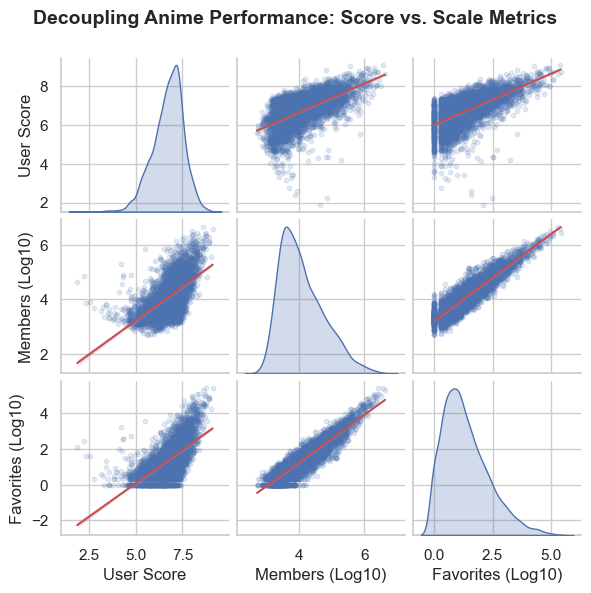

In [26]:
# =========================
# RELATIONSHIPS / CORRELATIONS
# =========================

# 22. Analyze correlation between:
#     score and popularity.

# 23. Analyze correlation between:
#     score and members.

# 24. Analyze correlation between:
#     favorites and score.

# 25. Analyze correlation between:
#     duration and score.

# 26. Analyze correlation between:
#     episode count and popularity.

# ===========================
plot_data = anime_df[["score", "members", "favorites"]].dropna().copy()

# Remove absolute zero entries to prevent log(0) math errors
plot_data = plot_data[(plot_data["members"] > 0) & (plot_data["favorites"] > 0)]

plot_data["log_members"] = np.log10(plot_data["members"])
plot_data["log_favorites"] = np.log10(plot_data["favorites"])

final_matrix_data = plot_data[["score", "log_members", "log_favorites"]]
sns.set_theme(style="whitegrid")

g = sns.pairplot(
    data=final_matrix_data,
    kind="reg",
    diag_kind="kde",
    plot_kws={
        "ci": 95,  # Explicitly requests the 95% confidence interval band
        "n_boot": 100,  # Fast bootstrapping so your notebook doesn't freeze
        "color": "#C44E52",
        "scatter_kws": {
            "alpha": 0.15,
            "s": 10,
            "color": "#4C72B0",
        },
        "line_kws": {
            "linewidth": 1.5,  # Keep your custom thickness here
        },
    },
    height=2,
)

g.axes[0, 0].set_ylabel("User Score")
g.axes[1, 0].set_ylabel("Members (Log10)")
g.axes[2, 0].set_ylabel("Favorites (Log10)")

g.axes[2, 0].set_xlabel("User Score")
g.axes[2, 1].set_xlabel("Members (Log10)")
g.axes[2, 2].set_xlabel("Favorites (Log10)")

g.figure.subplots_adjust(top=0.9)
g.figure.suptitle(
    "Decoupling Anime Performance: Score vs. Scale Metrics",
    fontsize=14,
    fontweight="bold",
)

plt.show()

# Advanced Analysis

In [27]:
# =========================
# ADVANCED ANALYSIS
# =========================

# 27. Find underrated anime:
#     high score + low popularity.
# see overrated_anime.sql

# sort -> members, score (True, False)?
# The correct sorting strategy:

# criterion: members < 10000, score > 6.5
underrated_anime = (
    anime_df[['title_english', 'members', 'score']]
    .sort_values(by=["members", "score"], ascending=[True, False])
    .query('members < 10000 and score > 7.5')
)
underrated_anime.head()

,title_english,members,score
2655,Energetic Bomb Ganbaruger,2183,7.56
3554,Galactic Gale Sasuraiger,2245,7.53
2945,Uchuusen Sagittarius,2343,7.52
2586,Time Quest,3147,7.64
2529,Juuni Senshi Bakuretsu Eto Ranger,3336,7.79


In [28]:
# 28. Find overrated anime:
#     low score + very high popularity.
# see overrated_anime.sql

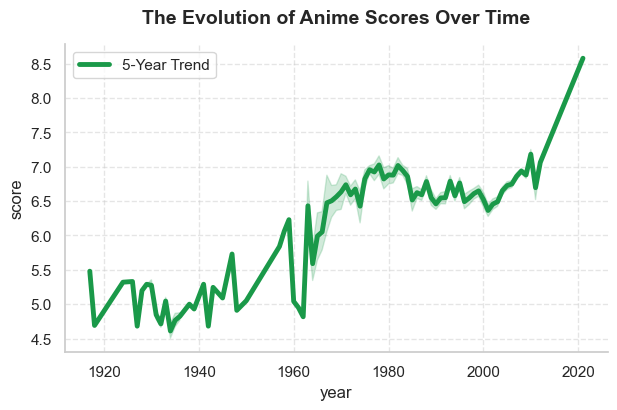

In [29]:
# 29. Analyze how anime scores changed over years.
# group by year -> mean
# group by year bins -> mean / score?
# each year -> each score (which sucks)
# any other ideas?

smoothed_score = anime_df.groupby('year')['score'].transform(
    lambda x: x.rolling(window=5, min_periods=1, center=True).mean()
)

# yearly_averages = anime_df.groupby('year')['score'].mean().reset_index()
# yearly_averages
plt.figure(figsize=(7, 4))

sns.lineplot(
    data=anime_df, 
    x="year",               # The column for your horizontal time axis
    y=smoothed_score,              # The column for your vertical average score axis
    color="#1A9949",       # A vibrant, eye-catching neon orange/red
    linewidth=3.5,         # Thicker line so it jumps off the screen
    marker="",            # Adds distinct dots on each year point
    markersize=6,          # Makes those dots visible
    markerfacecolor="white", # Contrasting center for the dots
    markeredgewidth=2,     # Crisp border around the dots
    label="5-Year Trend"
)

# Clean up the chart junk
plt.title("The Evolution of Anime Scores Over Time", fontsize=14, pad=15, weight='bold')
plt.grid(True, linestyle="--", alpha=0.5) # Soft background grid lines
sns.despine() # Removes the top and right border lines



P-value: 0.00003
Difference in Means: -0.1198


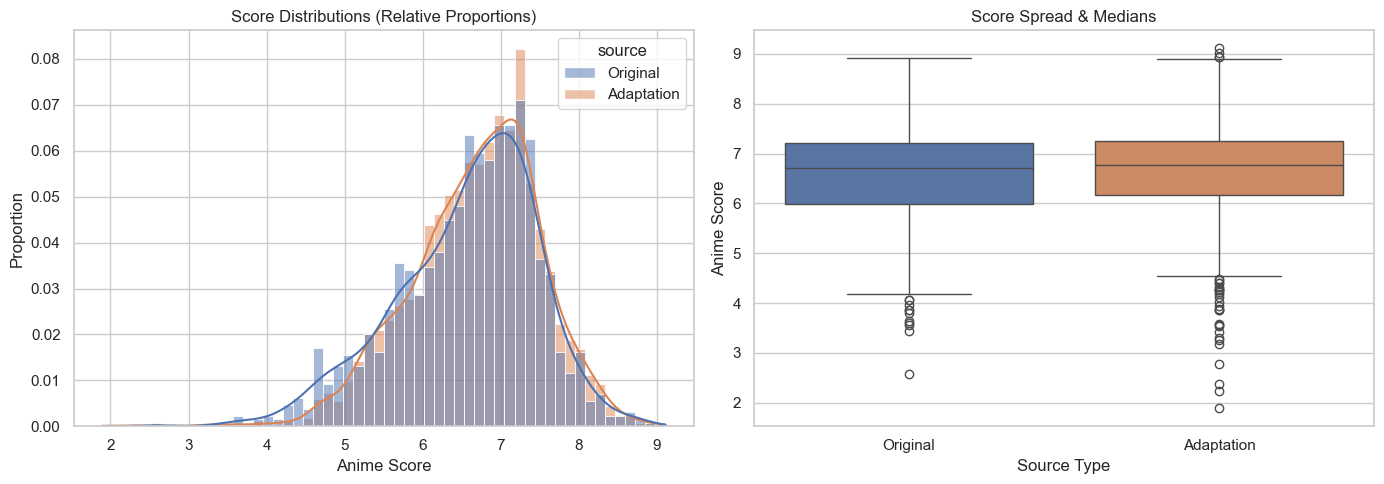

In [30]:
# 30. Analyze whether Originals or Adaptations score higher.
originals_score = (
    anime_df
    .query('source == "Original"')['score']
    .dropna()
)

adaptations_score = (
    anime_df
    .query('source != "Original"')['score']
    .dropna()
)

# H0: originals and adaptations means are equal
# H1: not equal

# sns.histplot(anime_df, x='score', hue=anime_df['source'].apply(lambda x: 'Original' if x == 'Original' else 'Adaptation'))  # original-adaptation

source_binarized = (
    anime_df[['source', 'score']]
    .assign(source=lambda df_step: np.where(df_step['source'] == 'Original', 'Original', 'Adaptation'))
    .dropna()
)

originals = source_binarized[source_binarized['source'] == 'Original']['score']
adaptations = source_binarized[source_binarized['source'] == 'Adaptation']['score']
t_stat, p_value = stats.ttest_ind(originals, adaptations, equal_var=False)

print(f"P-value: {p_value:.5f}")
print(f"Difference in Means: {originals.mean() - adaptations.mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=source_binarized, 
    x='score', 
    hue='source', 
    kde=True, 
    stat="proportion", 
    common_norm=False, 
    ax=axes[0]
)
axes[0].set_title('Score Distributions (Relative Proportions)')
axes[0].set_xlabel('Anime Score')

sns.boxplot(
    data=source_binarized,  # Note: updated to use your main binarized dataframe
    x='source', 
    y='score', 
    hue='source', 
    legend=False,           # Removes duplicate legend since hue is used
    ax=axes[1]
)
axes[1].set_title('Score Spread & Medians')
axes[1].set_xlabel('Source Type')
axes[1].set_ylabel('Anime Score')

plt.tight_layout()

# declined H0

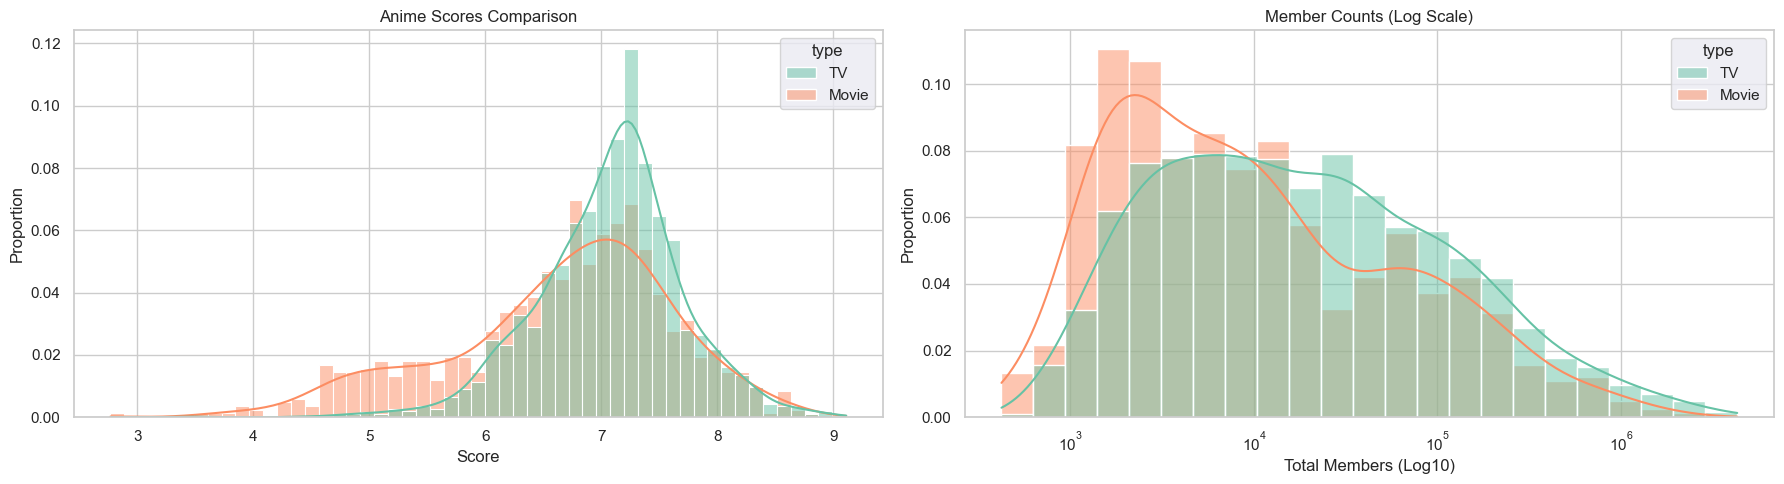

In [31]:
# 31. Compare Movies vs TV series:
#     score, popularity, favorites, duration.

plot_data = anime_df.copy()
plot_data = plot_data[plot_data['type'].isin(['TV', 'Movie'])]

# tv_type = plot_data.query('type == "TV"')
# movie_type = plot_data.query('type == "Movie"')

# multiple histograms, hue='type'
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.set_theme(palette='Set2')

# --- Subplot 1: Score Distribution ---
sns.histplot(
    data=plot_data,
    x='score',
    hue='type',
    kde=True,
    stat="proportion",
    common_norm=False,
    ax=axes[0]
)
axes[0].set_title('Anime Scores Comparison')
axes[0].set_xlabel('Score')

# --- Subplot 2: Members (Log Scale) ---
sns.histplot(
    data=plot_data,
    x='members',
    hue='type',
    kde=True,
    stat="proportion",
    common_norm=False,
    log_scale=True,  # Compresses the 0 to 1M+ variance beautifully
    ax=axes[1]
)
axes[1].set_title('Member Counts (Log Scale)')
axes[1].set_xlabel('Total Members (Log10)')



# 3. Adjust spacing smoothly across all three plots
plt.tight_layout()

# sns.histplot(data=plot_data)

In [32]:
# 32. Find the most genre-diverse studios.
from collections import Counter

total_studio_genres = (
    anime_df[['studios', 'genres']]
    .explode('studios')
    .explode('genres')
    .dropna()
    .groupby('studios')['genres']
    .agg(list)
    .apply(lambda x: {
        'unique_genres_count': len(set(x)),
        'top_3_genres': Counter(x).most_common(3)
    })
    .apply(pd.Series)
    .reset_index()
    .sort_values('unique_genres_count', ascending=False)
)

total_studio_genres.head()

,studios,unique_genres_count,top_3_genres
144,J.C.Staff,20,"[(Comedy, 97), (Romance, 51), (Drama, 48)]"
182,Madhouse,20,"[(Drama, 92), (Action, 80), (Comedy, 80)]"
303,Studio Deen,19,"[(Comedy, 71), (Action, 45), (Drama, 34)]"
246,Production I.G,19,"[(Drama, 37), (Sci-Fi, 36), (Comedy, 35)]"
119,Group TAC,18,"[(Comedy, 43), (Drama, 24), (Adventure, 23)]"


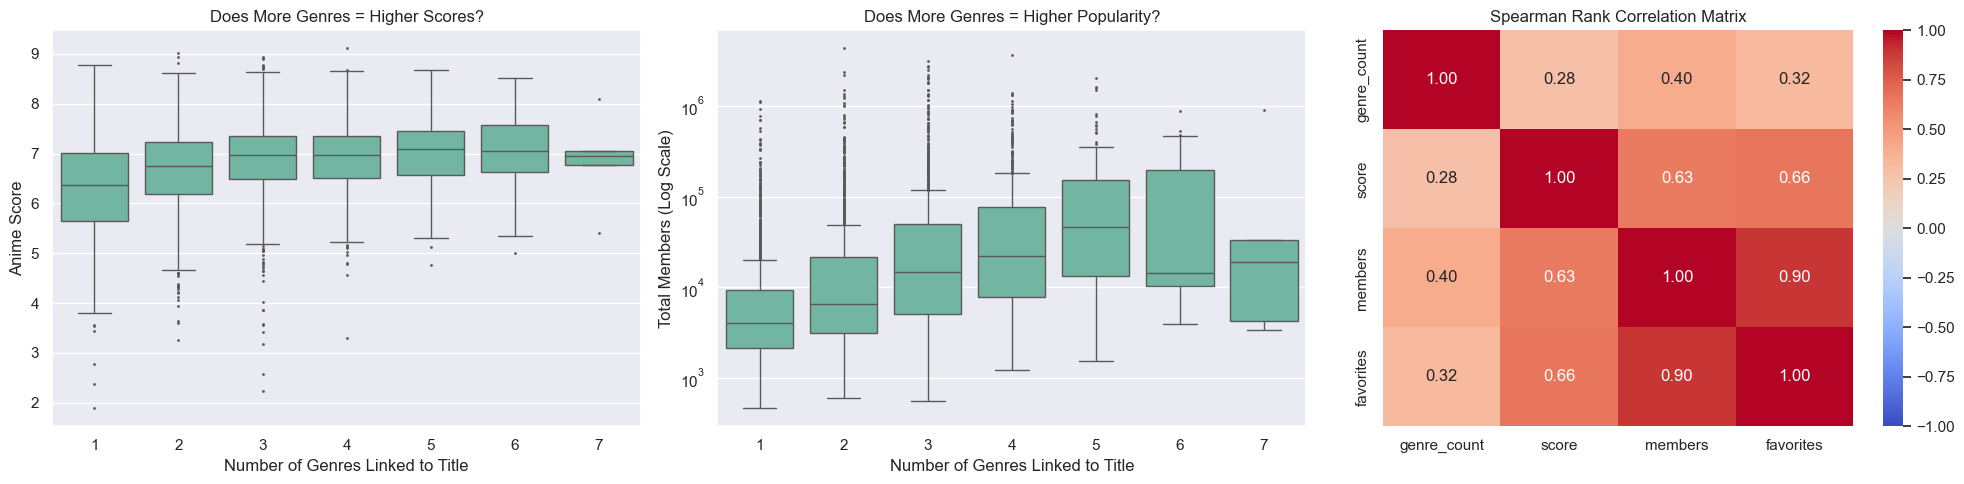

In [33]:
# 33. Analyze multi-genre anime:
#     do more genres correlate with popularity or score?

genre_analysis_df = (
    anime_df[['genres', 'score', 'members', 'favorites']]
    .assign(genre_count=lambda x: x['genres'].map(len))
    .query('genre_count > 0')
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.boxplot(
    data=genre_analysis_df,
    x='genre_count',
    y='score',
    ax=axes[0],
    fliersize=1
)
axes[0].set_title('Does More Genres = Higher Scores?')
axes[0].set_xlabel('Number of Genres Linked to Title')
axes[0].set_ylabel('Anime Score')

sns.boxplot(
    data=genre_analysis_df,
    x='genre_count',
    y='members',
    ax=axes[1],
    fliersize=1
)
axes[1].set_yscale('log')
axes[1].set_title('Does More Genres = Higher Popularity?')
axes[1].set_xlabel('Number of Genres Linked to Title')
axes[1].set_ylabel('Total Members (Log Scale)')

corr_matrix = genre_analysis_df[['genre_count', 'score', 'members', 'favorites']].corr(method='spearman')

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    vmin=-1,
    vmax=1,
    ax=axes[2],
    cbar=True
)
axes[2].set_title('Spearman Rank Correlation Matrix')

plt.tight_layout()


<>:98: SyntaxWarning: invalid escape sequence '\g'
<>:98: SyntaxWarning: invalid escape sequence '\g'
C:\Users\Artem\AppData\Local\Temp\ipykernel_10268\2630946146.py:98: SyntaxWarning: invalid escape sequence '\g'
  "Anime Studio Collaboration Network\n(Studios with $\geq$ 5 Total Partnerships)",


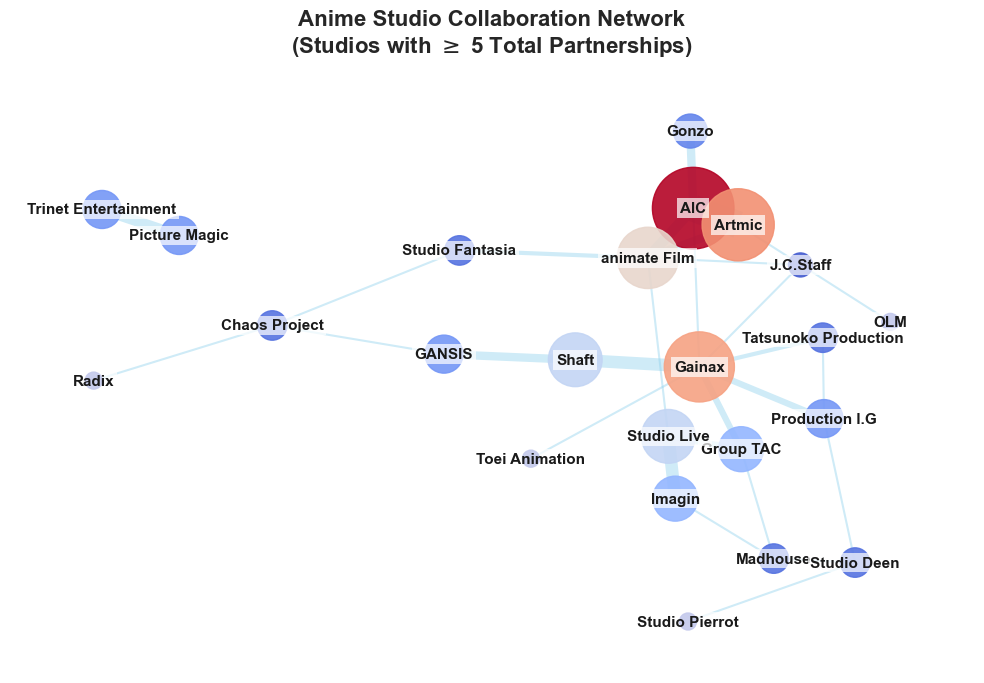

In [34]:
# 34. Analyze long-running anime separately. ???
# 35. Build a studio collaboration network.
# how?
# it should look like weighted graph?
# if [s1 s2 s3] -> 3 connections [s1 s2] [s2 s3] [s3 s1]

# in general:
# [s1 ... sn] -> all possible pairs
# and from this build adjacency matrix (or how its called)
# and build graph from it
# i need sth like "named matrix"

from itertools import combinations
import networkx as nx

def collab_to_matrix(collab_list):
    # 1. Flatten all lists to find every unique studio involved
    unique_studios = sorted(
        list(set(studio for anime in collab_list for studio in anime))
    )

    matrix = pd.DataFrame(
        0, index=unique_studios, columns=unique_studios, dtype=int
    )

    for anime in collab_list:
        for studio_a, studio_b in combinations(sorted(anime), 2):
            matrix.loc[studio_a, studio_b] += 1
            matrix.loc[studio_b, studio_a] += 1

    return matrix


def filter_collaborations(collab_matrix: pd.DataFrame, n: int) -> pd.DataFrame:
    frequent_studios = (
        collab_matrix.sum(axis=1).where(lambda x: x >= n).dropna().index
    )
    shrunken_matrix = collab_matrix.loc[frequent_studios, frequent_studios]
    return shrunken_matrix


collab_indices = (
    anime_df['studios']
    .map(len)
    .where(lambda x: x > 1)
    .dropna()
    .index
)

unique_studios = (
    anime_df.iloc[collab_indices]['studios']
    .explode()
    .unique()
    .tolist()
)

collaborations = (
    anime_df.iloc[collab_indices]['studios']
    .map(list)  # Converts inner arrays/tuples to pure lists
    .tolist()   # Converts the outer Series to a list
)

collaboration_matrix = collab_to_matrix(collaborations)
collaboration_matrix = filter_collaborations(collaboration_matrix, 5)


G = nx.from_pandas_adjacency(collaboration_matrix)
# G.remove_edges_from(nx.selfloop_edges(G))

node_degrees = dict(G.degree(weight="weight"))
node_sizes = [v * 150 for v in node_degrees.values()]
edge_widths = [d["weight"] * 1.5 for u, v, d in G.edges(data=True)]

plt.figure(figsize=(10, 7), dpi=100)
pos = nx.spring_layout(G, k=1.1, iterations=100, seed=42)

nx.draw_networkx_edges(
    G, pos, width=edge_widths, edge_color="skyblue", alpha=0.4
)
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=list(node_degrees.values()),
    cmap=plt.cm.coolwarm,
    alpha=0.9,
)
nx.draw_networkx_labels(
    G,
    pos,
    font_size=11,
    font_weight="bold",
    font_family="sans-serif",
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=2),
)

plt.title(
    "Anime Studio Collaboration Network\n(Studios with $\geq$ 5 Total Partnerships)",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.axis("off")
plt.tight_layout()



In [35]:
# 36. Find niche genres with highest average scores.
# what means niche? not popular?

genre_stats = (
    anime_df[['genres', 'members', 'score']]
    .explode('genres')
    .dropna()
    .groupby('genres')
    .agg(
        avg_score=('score', 'mean'),
        total_audience=('members', 'sum')
    )
)

# genre_stats
niche_cutoff = genre_stats["total_audience"].quantile(0.2)

niche_genres_ranked = (
    genre_stats.query("total_audience <= @niche_cutoff")
    .sort_values(by="avg_score", ascending=False)
)

niche_genres_ranked

,avg_score,total_audience
genres,,
Slice of Life,7.074066,4280663
Gourmet,6.992500,705834
Girls Love,6.657381,1805814
Erotica,6.196364,651138
Boys Love,6.186885,2440235


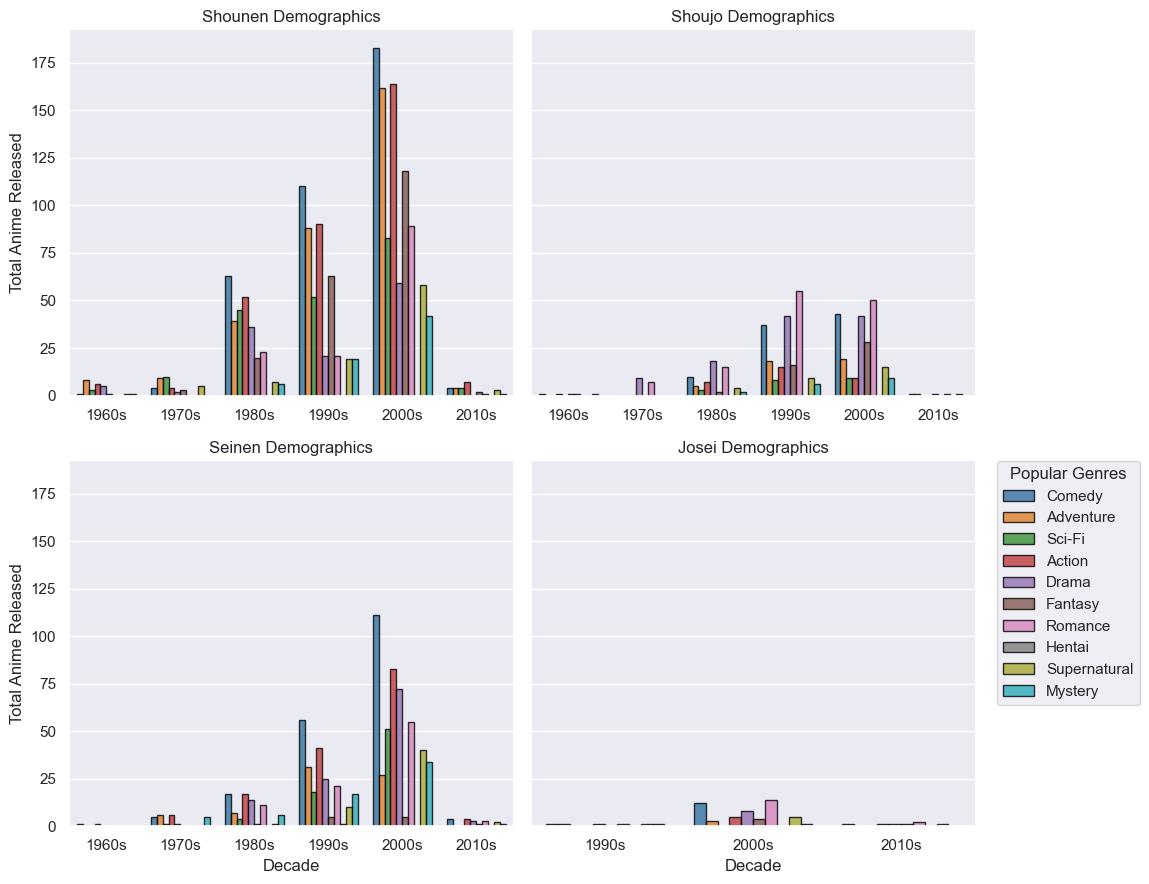

In [36]:
# 37. Analyze trends in anime demographics over time.
# shounen, shoujo ... 
# what trends mean?

demographics = ["Shounen", "Shoujo", "Seinen", "Josei"]

# ######## Genres trend ############################################################################
# for each group - facet
# for 10-year intervals - separate barplots
demo_df = (
    anime_df[['year', 'genres', 'demographics', 'score']]
    .explode('demographics')
    .explode('genres')
    .dropna()
    .assign(decade=lambda x: (x['year'] // 10 * 10).astype(int).astype(str) + "s" )
    .query('demographics in @demographics')
)

popular_genres = (
    anime_df.explode("genres")["genres"].value_counts().head(10).index.to_list()
)

trend_data = (
    demo_df.groupby(["decade", "demographics"])
    .size()
    .reset_index(name="anime_count")
)

# plot
# facet by demographics
# for each decade barplot popular genre counts

grid_data = (
    demo_df.query("genres in @popular_genres")
    .groupby(["demographics", "decade", "genres"])
    .size()
    .reset_index(name="anime_count")
)

g = sns.FacetGrid(
    grid_data,
    col="demographics",
    col_order=demographics,
    sharex=False,
    sharey=True,
    height=4.5,
    aspect=1.3,
    col_wrap=2,
)


def draw_decade_bars(data, **kwargs):
    sns.barplot(
        data=data,
        x="decade",
        y="anime_count",
        hue="genres",
        hue_order=popular_genres,
        palette="tab10",
        edgecolor="black",
        alpha=0.8,
    )
    if plt.gca().get_legend() is not None:
        plt.gca().get_legend().remove()


g.map_dataframe(draw_decade_bars)

g.set_titles("{col_name} Demographics")
g.set_axis_labels("Decade", "Total Anime Released")

plt.legend(
    title="Popular Genres",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0,
)
plt.tight_layout()


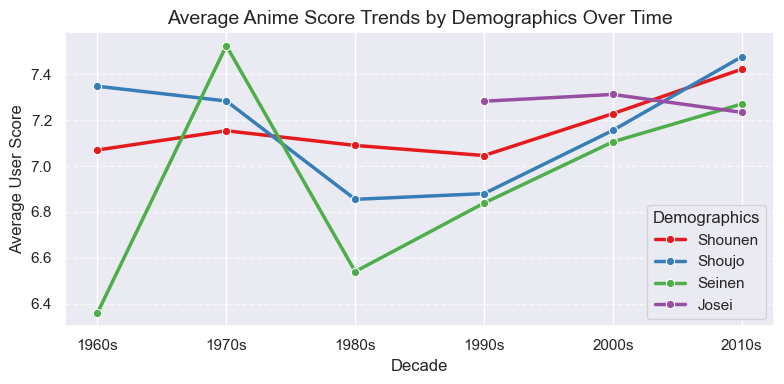

In [37]:
# ###### Scoring trend ############################################################################ 
# For each decade plot score hued by demographics (all on a single plot)
demo_df['score']

score_trend = (
    demo_df.groupby(["decade", "demographics"])["score"]
    .mean()
    .reset_index(name="avg_score")
)

score_trend = score_trend.sort_values("decade")

plt.figure(figsize=(8, 4))

sns.lineplot(
    data=score_trend,
    x="decade",
    y="avg_score",
    hue="demographics",
    hue_order=demographics,
    marker="o",
    linewidth=2.5,
    palette="Set1",
)

plt.title("Average Anime Score Trends by Demographics Over Time", fontsize=14)
plt.xlabel("Decade", fontsize=12)
plt.ylabel("Average User Score", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(title="Demographics", frameon=True)

plt.tight_layout()


In [38]:
# 38. Identify outliers in:
# Members, Favorites

outlier_features = ['members', 'favorites', 'score']

def find_outliers(series):
    '''returns indices of outliers'''
    clean_series = series.dropna()
    q1 = clean_series.quantile(0.25)
    q3 = clean_series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return (series < lower_bound) | (series > upper_bound)

outlier_dfs = [anime_df[['title_english', 'year', *outlier_features]].iloc[find_outliers(anime_df[feature])] for feature in outlier_features]

outlier_dfs[0].head()


,title_english,year,members,favorites,score
0,Cowboy Bebop,1998,2057323,89639,8.75
1,Cowboy Bebop: The Movie,2001,412138,1785,8.38
2,Trigun,1998,834750,17659,8.22
3,Witch Hunter Robin,2002,129851,712,7.26
5,Eyeshield 21,2005,196237,2128,7.92


era
Modern    2826
Old       2146
Name: count, dtype: int64


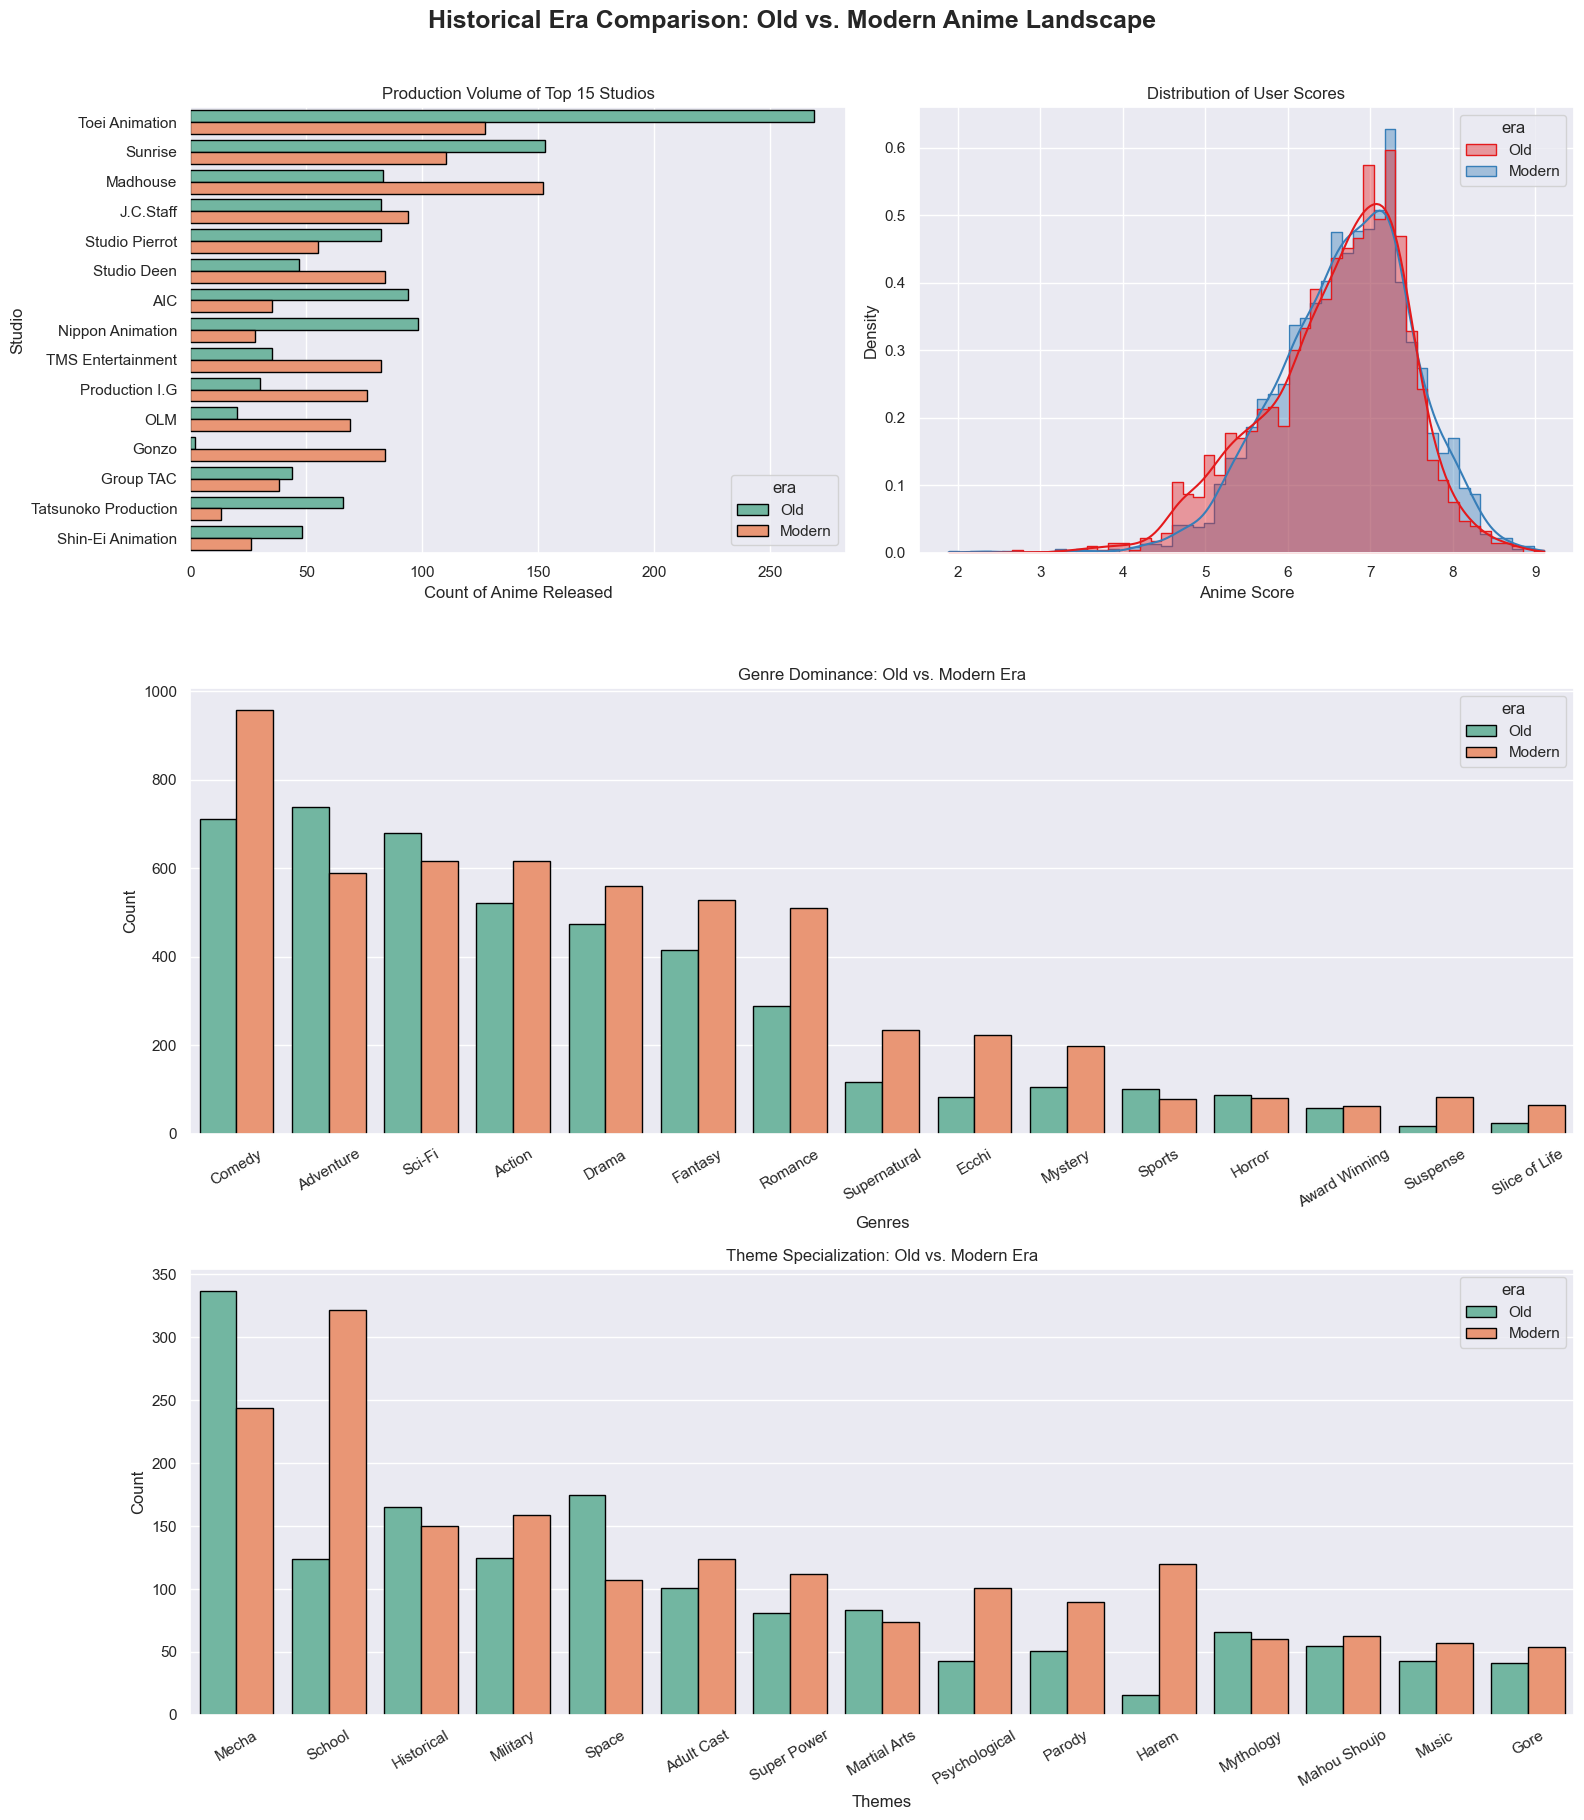

In [39]:
# 39. Compare old anime vs modern anime.

old_threshold = 2000
old_df = anime_df[anime_df['year'] > old_threshold]
new_df = anime_df[anime_df['year'] > old_threshold]

# how to compare?
# studio count (like some studios were active in the past or sth)
# genre/themes specialization
# scores
# members/favorites
# rating
# source (original/adaptation)
# type

# sources = anime_df['source'].unique().tolist()
# adaptations = set(sources) - set(['Original'])

def process_base_features(df: pd.DataFrame) -> pd.DataFrame:
    return df.assign(
        era=lambda x: np.where(x["year"] < 2000, "Old", "Modern"),
        source_type=lambda x: np.where(
            x["source"].isin(["Original"]), "Original", "Adaptation"
        ),
    )


processed_df = process_base_features(anime_df)
studios_df = processed_df.explode("studios").dropna()
genres_df = processed_df.explode("genres").dropna()
themes_df = processed_df.explode("themes").dropna()
print(processed_df['era'].value_counts())

# i think i need to hue by old/new
# for studios horizontal barplot
# for genres barplot
# for themes barplot
# for score histograms or boxplots?

layout = [["studios", "scores"], ["genres", "genres"], ["themes", "themes"]]

fig, axs = plt.subplot_mosaic(layout, figsize=(16, 18))
era_order = ["Old", "Modern"]
palette = "Set2"

# ==========================================
# SUBPLOT 1: Top 15 Studios (Horizontal)
# ==========================================
top_studios = studios_df["studios"].value_counts().head(15).index
sns.countplot(
    data=studios_df[studios_df["studios"].isin(top_studios)],
    y="studios",
    hue="era",
    hue_order=era_order,
    order=top_studios,
    palette=palette,
    edgecolor="black",
    ax=axs["studios"],
)
axs["studios"].set_title("Production Volume of Top 15 Studios")
axs["studios"].set_xlabel("Count of Anime Released")
axs["studios"].set_ylabel("Studio")

# ==========================================
# SUBPLOT 2: Score Distributions (KDE/Hist)
# ==========================================
sns.histplot(
    data=processed_df,
    x="score",
    hue="era",
    hue_order=era_order,
    kde=True,
    element="step",
    stat="density",
    common_norm=False,
    palette="Set1",
    alpha=0.4,
    ax=axs["scores"],
)
axs["scores"].set_title("Distribution of User Scores")
axs["scores"].set_xlabel("Anime Score")
axs["scores"].set_ylabel("Density")

# ==========================================
# SUBPLOT 3: Genre Dominance (Full Width)
# ==========================================
top_genres = genres_df["genres"].value_counts().head(15).index
sns.countplot(
    data=genres_df[genres_df["genres"].isin(top_genres)],
    x="genres",
    hue="era",
    hue_order=era_order,
    order=top_genres,
    palette=palette,
    edgecolor="black",
    ax=axs["genres"],
)
axs["genres"].set_title("Genre Dominance: Old vs. Modern Era")
axs["genres"].set_xlabel("Genres")
axs["genres"].set_ylabel("Count")
axs["genres"].tick_params(axis="x", labelrotation=30)

# ==========================================
# SUBPLOT 4: Theme Specialization (Full Width)
# ==========================================
top_themes = themes_df["themes"].value_counts().head(15).index
sns.countplot(
    data=themes_df[themes_df["themes"].isin(top_themes)],
    x="themes",
    hue="era",
    hue_order=era_order,
    order=top_themes,
    palette=palette,
    edgecolor="black",
    ax=axs["themes"],
)
axs["themes"].set_title("Theme Specialization: Old vs. Modern Era")
axs["themes"].set_xlabel("Themes")
axs["themes"].set_ylabel("Count")
axs["themes"].tick_params(axis="x", labelrotation=30)


plt.suptitle(
    "Historical Era Comparison: Old vs. Modern Anime Landscape",
    fontsize=18,
    weight="bold",
    y=1.01,
)
plt.tight_layout()



# Recommendation metric

In [ ]:
# 40. Build a simple recommendation similarity metric.

# how can i define metric (does it need to hold metric space axioms?)
# what should it look like?
# example:
# some guy watched some animes (animes -> indices)
# what did he choose as favorites
# scores he gave to animes 

# if no animes watched/added to fav: just recommend most popular
# 
# how to take into account scores given to these:
# compute genre weights (favorites, or if not: watched scored)
# compute theme weights (the same way)

from dataclasses import dataclass, field
from typing import Dict, List, Set


@dataclass
class UserProfile:
    user_id: int | str
    watched_scores: Dict[int, int] = field(default_factory=dict)  # {anime_id: user_rating}
    favorites: Set[int] = field(default_factory=set)  # set for O(1)?

    @property
    def is_new_user(self) -> bool:
        """Returns True if the user has no history, triggering the fallback."""
        return not self.watched_scores and not self.favorites

    @property
    def average_score(self) -> float:
        """Computes the user's personal scoring baseline."""
        if not self.watched_scores:
            return 5.0  # base avg score
        return sum(self.watched_scores.values()) / len(self.watched_scores)
    
    def __str__(self) -> str:
        lines = [
            f"👤 Profile: {self.user_id}",
            f"📊 History Size: {len(self.watched_scores)} titles",
            f"⭐ Average Score Given: {self.average_score:.2f}",
            "📝 Watched History (Anime ID -> Score):",
        ]

        for anime_id, score in self.watched_scores.items():
            is_fav = " ❤️ [FAVORITE]" if int(anime_id) in self.favorites else ""
            lines.append(f"   ▪️ ID {int(anime_id):<5} : {float(score):.1f}{is_fav}")

        return "\n".join(lines)


def get_random_user(df: pd.DataFrame, n_watched, n_favs, id, seed=42) -> UserProfile:
    assert n_favs <= n_watched
    
    np.random.seed(seed)
    username = f"User_{id}"
    all_genres = df["genres"].explode().dropna().unique()
    all_themes = df["themes"].explode().dropna().unique()

    sampled_genres = np.random.choice(
        all_genres, size=min(2, len(all_genres)), replace=False
    )
    sampled_themes = np.random.choice(
        all_themes, size=min(1, len(all_themes)), replace=False
    )

    has_target_genre = df["genres"].apply(
        lambda g_list: any(g in sampled_genres for g in g_list)
        if isinstance(g_list, list)
        else False
    )
    has_target_theme = df["themes"].apply(
        lambda t_list: any(t in sampled_themes for t in t_list)
        if isinstance(t_list, list)
        else False
    )

    pool_indices = df[has_target_genre | has_target_theme].index

    if len(pool_indices) < n_watched:
        pool_indices = df.index

    watched_ids = np.random.choice(pool_indices, size=n_watched, replace=False)
    raw_scores = np.random.normal(loc=7.5, scale=1.5, size=n_watched)
    clipped_scores = np.clip(raw_scores, 1.0, 10.0).round(1)
    watched_scores = dict(zip(watched_ids, clipped_scores))

    actual_n_favs = min(n_favs, n_watched)
    fav_ids = set(np.random.choice(watched_ids, size=actual_n_favs, replace=False))

    return UserProfile(
        user_id=username, watched_scores=watched_scores, favorites=fav_ids
    )



👤 Profile: User_0
📊 History Size: 10 titles
⭐ Average Score Given: 6.75
📝 Watched History (Anime ID -> Score):
   ▪️ ID 3659  : 7.3
   ▪️ ID 4729  : 6.3
   ▪️ ID 2304  : 6.3
   ▪️ ID 4273  : 5.6 ❤️ [FAVORITE]
   ▪️ ID 1270  : 6.8 ❤️ [FAVORITE]
   ▪️ ID 2389  : 5.8
   ▪️ ID 240   : 5.9
   ▪️ ID 4282  : 7.9
   ▪️ ID 4178  : 7.4 ❤️ [FAVORITE]
   ▪️ ID 239   : 8.2


In [ ]:

# =========================================================================

def popularity_based(df: pd.DataFrame, top_n: int = 10) -> pd.DataFrame:
    """User profile doesn't contain neither watched or favorites or score.
    Returns the top N highest-rated anime among mainstream titles.
    """
    popularity_threshold = df["members"].quantile(0.75)
    return (
        df
        .query("members >= @popularity_threshold")
        .sort_values(by="score", ascending=False)
        .head(top_n)
    )


def compute_weights(
    user: UserProfile, df: pd.DataFrame, column_name: str
) -> dict:
    """Computes a profile dictionary of weights for a specific categorical list column

    (e.g., 'genres' or 'themes') using optimized vector-mapping operations.
    """
    user_baseline = user.average_score
    
    all_interacted_ids = list(
        set(user.watched_scores.keys()).union(user.favorites)
    )

    valid_ids = [i for i in all_interacted_ids if i in df.index]
    if not valid_ids:
        return {}

    raw_scores = pd.Series(
        [user.watched_scores.get(i, user_baseline) for i in valid_ids],
        index=valid_ids,
    )
    score_impacts = raw_scores - user_baseline  # centered scores
    is_favorite = pd.Series([i in user.favorites for i in valid_ids], index=valid_ids)  # mask?
    score_impacts += 2.0 * is_favorite
    
    tags_series = df.loc[valid_ids, column_name].explode()  # exploded values, say genres. Anime idx -> genre
    weights_series = tags_series.map(score_impacts).groupby(tags_series).sum() # Anime idx -> genre -> score . groupby . sum?

    return weights_series.to_dict()  # weight for each genre/theme


def favorites_based_score(user: UserProfile, df: pd.DataFrame) -> pd.Series:
    """Calculates an integrated affinity score for every anime in the dataset

    based on the aggregate weights of its combined genres and themes.
    """
    genre_weights = compute_weights(user, df, "genres")
    theme_weights = compute_weights(user, df, "themes")

    print(genre_weights, theme_weights, sep='\n')  # why zeros?
    
    # 2. Vector scoring function applied element-wise across the dataframe rows
    def calculate_row_affinity(row):
        g_score = sum(genre_weights.get(g, 0.0) for g in row["genres"])
        t_score = sum(theme_weights.get(t, 0.0) for t in row["themes"])

        total_score = g_score + t_score
        total_tags = len(row["genres"]) + len(row["themes"])

        return total_score / total_tags if total_tags > 0 else 0.0

    recommendation_scores = df.apply(calculate_row_affinity, axis=1)
    already_watched = list(user.watched_scores.keys())
    valid_watched_ids = df.index.intersection(already_watched)
    recommendation_scores.loc[valid_watched_ids] = -999.0

    return recommendation_scores




{'Comedy': 0.0, 'Girls Love': 0.0, 'Romance': 0.0, 'Sci-Fi': 0.0}
{'Mecha': 0.0, 'School': 0.0}


5015      0.0
0         0.0
1         0.0
2         0.0
3         0.0
        ...  
12        0.0
4488   -999.0
2603   -999.0
2516   -999.0
1401   -999.0
Length: 4972, dtype: float64

In [172]:
def get_feature_weights(user: UserProfile, df: pd.DataFrame, feature):
    user_baseline = user.average_score
    
    trunc_df = df[['mal_id', feature]]
    user_watched_scores = pd.DataFrame(list(user.watched_scores.items()), columns=['mal_id', 'user_score'])
    favorites = list(user.favorites)
    watched_anime_profiles = pd.merge(
        trunc_df, user_watched_scores, on="mal_id", how="inner"
    )
    
    watched_anime_profiles["is_favorite"] = watched_anime_profiles["mal_id"].isin(favorites)  # add fav column mask
    watched_anime_profiles["score_centered"] = watched_anime_profiles['user_score'] - user_baseline  # score centered
    watched_anime_profiles["weights"] = (
        watched_anime_profiles["score_centered"] + (watched_anime_profiles["is_favorite"] * 2.0)
    ).clip(lower=0)
    
    # and for each feature (genre/theme) i need to compute weight (normalized)?
    feature_weights = (
        watched_anime_profiles[[feature, 'weights']]
        .explode(feature)
        .dropna()
        .groupby(feature)['weights']
        .mean()
    )
    return feature_weights.to_dict()


def get_recommended_anime(user: UserProfile, df: pd.DataFrame, n):
    # dicts: str -> float
    genre_weights = get_feature_weights(test_user, anime_df, 'genres')
    theme_weights = get_feature_weights(test_user, anime_df, 'themes')
    
    recommendation_df = df.copy()[['mal_id', 'genres', 'themes']]
    recommendation_df['genres_score'] = recommendation_df["genres"].apply(
        lambda genre_list: sum(genre_weights.get(g, 0.0) for g in genre_list)
    )
    recommendation_df['themes_score'] = recommendation_df["themes"].apply(
        lambda theme_list: sum(theme_weights.get(t, 0.0) for t in theme_list)
    )
    recommendation_df['overall_score'] = recommendation_df['genres_score'] + recommendation_df['themes_score'] 
    
    # exclude watched animes
    watched_ids = list(user.watched_scores.keys())
    unwatched_df = recommendation_df[~recommendation_df["mal_id"].isin(watched_ids)]
    top_recommendations = unwatched_df.sort_values(
        by="overall_score", ascending=False
    ).head(n)
    
    return top_recommendations



# genres mapping structure: 
# {'Action': 0.0, 'Adventure': 0.47500000000000053, 'Comedy': 0.47500000000000053, 'Hentai': 1.950000000000001, 'Sci-Fi': 0.816666666666667}


test_user = get_random_user(anime_df, 10, 3, 1)
get_recommended_anime(test_user, anime_df, n=5)

,mal_id,genres,themes,genres_score,themes_score,overall_score
1465,1611,"[Adventure, Drama, Horror, Mystery, Sci-Fi, Su...","[Military, Psychological]",6.500,2.050,8.550
143,165,"[Award Winning, Drama, Mystery, Romance, Sci-F...","[Mecha, Music, Psychological]",7.375,1.025,8.400
74,95,"[Adventure, Award Winning, Drama, Romance, Sci...","[Mecha, Military, Space]",5.050,3.075,8.125
996,1096,"[Award Winning, Drama, Mystery, Sci-Fi]","[Detective, Mecha, Military]",4.925,3.075,8.000
439,468,"[Award Winning, Mystery, Sci-Fi, Suspense]","[Adult Cast, Detective, Mecha, Military, Psych...",4.925,3.075,8.000
